In [1]:
import numpy as np

import scarf

scarf.configure_output(level="WARNING", progress=False)
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="tenx_10K_pbmc-v1_atacseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", default_assay="ATAC", nthreads=4)


In [2]:
def input_ref(ref, name):
    return scarf.ArtifactRef.from_dict(ds.inspect_artifact(ref).inputs[name])


[clusters] = ds.list_artifacts(
    from_assay="ATAC", kind="cluster_labels", complete_only=True
)
graph = input_ref(clusters, "graph")
neighbors = input_ref(graph, "neighbors")
ann_index = input_ref(neighbors, "ann_index")
lsi = input_ref(ann_index, "coordinates")
normalized = input_ref(lsi, "normalized")
cell_selection = input_ref(normalized, "cell_selection")
peak_features = input_ref(normalized, "feature_selection")
input_cell_selection = input_ref(cell_selection, "prior_cell_selection")
[umap] = ds.list_artifacts(from_assay="ATAC", kind="embedding", complete_only=True)
assert input_ref(umap, "graph") == graph

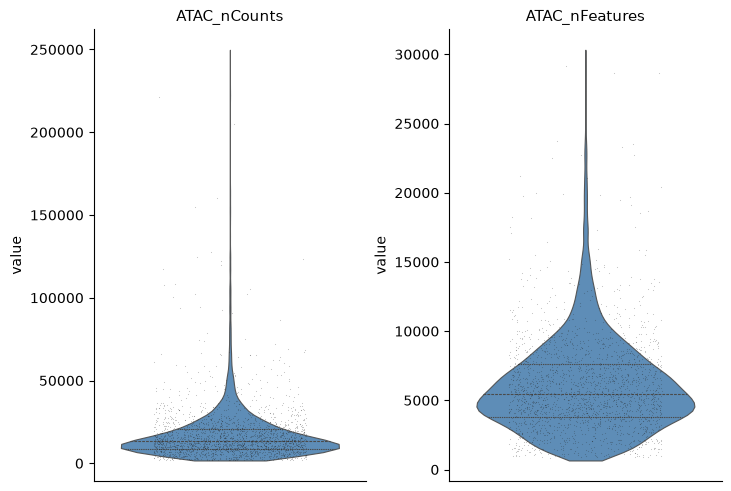

In [3]:
qc_cols = [c for c in ("ATAC_nCounts", "ATAC_nFeatures") if c in ds.cells.columns]
ds.plots.distribution(
    keys=qc_cols,
    cell_selection=input_cell_selection,
    kind="violin",
    max_points=2000,
)

In [4]:
input_mask = np.asarray(ds.load_artifact(input_cell_selection)["values"][:], dtype=bool)
cell_mask = np.asarray(ds.load_artifact(cell_selection)["values"][:], dtype=bool)
print(f"Cells in input selection: {int(input_mask.sum())}")
print(f"Cells after filter: {int(cell_mask.sum())}")

Cells in input selection: 8728
Cells after filter: 8426


In [5]:
peak_values = np.asarray(ds.load_artifact(peak_features)["values"][:])
print("Selected peaks:", int(peak_values.sum()))

Selected peaks: 25000


In [6]:
connectivity = ds.load_graph(graph)
connectivity.shape, connectivity.nnz

((8426, 8426), 176946)

In [7]:
cluster_values = np.asarray(ds.load_artifact(clusters)["values"][:])
np.unique(cluster_values, return_counts=True)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 array([2827,  179,  734,  385,  150,  786, 1081, 1191,   70,  299,   36,
         480,  208]))

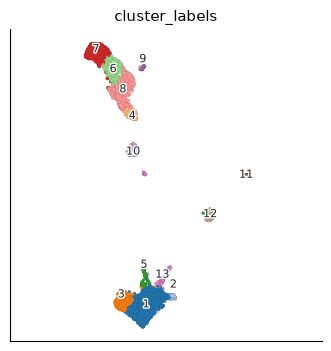

In [8]:
ds.plots.embedding(layout=umap, color_by=clusters)

In [9]:
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="annotations", destination="scarf_datasets"
)

Downloading bucket files: 4397159 / 4397159 complete

Downloading bytes: 4397159 / 4397159 complete

In [10]:
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn=f"{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz",
    peaks_col="ids",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)
print(
    "Valid GeneScores features:",
    int(ds.GeneScores.feats.fetch_all("I").sum()),
)

Valid GeneScores features: 62446
